In [ ]:
import pickle

# Specify the path to the pickle file you want to read
pickle_file_path = 'transaction.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path, 'rb') as file:
    # Load the data from the pickle file
    loaded_data = pickle.load(file)
# Now, the 'loaded_data' variable contains the deserialized Python object
# You can use 'loaded_data' as you would any other Python object

In [ ]:
# Filter rows where 'is_pending' is 'YANLIŞ' and 'direction' is either 'INFLOW' or 'OUTFLOW'
filtered_df = loaded_data[(loaded_data['is_deleted'] == False) & ((loaded_data['direction'] == 'INFLOW') | (loaded_data['direction'] == 'OUTFLOW'))]

# Now, 'filtered_df' contains the rows where 'is_pending' is 'YANLIŞ' and 'direction' is either 'INFLOW' or 'OUTFLOW'

In [ ]:
transactions=filtered_df

In [ ]:
import pandas as pd
# Group the DataFrame by the 'account_id' column

filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')
grouped_by_account = filtered_df.groupby('account_id')

# Create an empty dictionary to store the tables for each account
account_tables = {}

# Iterate over the groups (one group per unique 'account_id')
for account_id, group in grouped_by_account:
    # Within each 'account_id' group, group the data by 'datetime' and 'direction'
    # and calculate the sums of 'amount' separately for 'INFLOW' and 'OUTFLOW'
    inflow = group[group['direction'] == 'INFLOW'].groupby('new_datetime')['amount'].sum()
    outflow = group[group['direction'] == 'OUTFLOW'].groupby('new_datetime')['amount'].sum()

    # Combine the 'inflow' and 'outflow' Series into a DataFrame
    inflow_df = pd.DataFrame({'Datetime': inflow.index, 'INFLOW': inflow.values})
    outflow_df = pd.DataFrame({'Datetime': outflow.index, 'OUTFLOW': outflow.values})

    # Merge the 'inflow' and 'outflow' DataFrames on 'Datetime' column with 0 fillna
    account_table = inflow_df.merge(outflow_df, on='Datetime', how='outer').fillna(0)

    # Store the table for the current account in the dictionary
    account_tables[account_id] = account_table


<ipython-input-36-ffb9c59a72af>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')


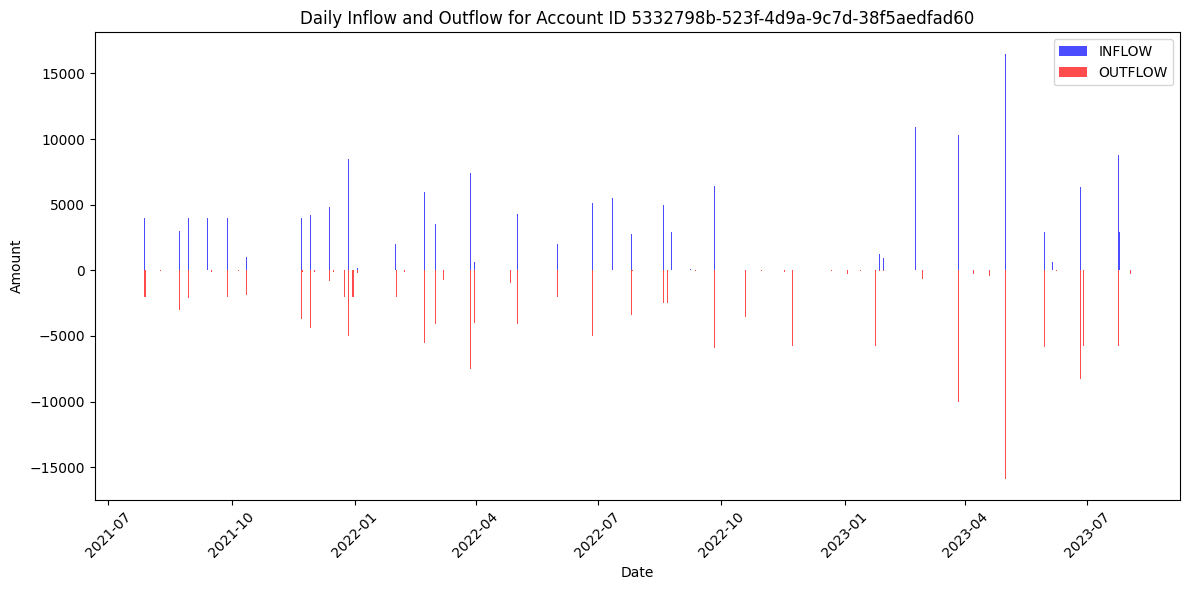

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
# This should be set up as described in previous conversations

# Function to generate a plot for a specific account_id
def plot_daily_inflow_outflow(account_id):
    if account_id not in account_tables:
        print(f"Account ID {account_id} not found.")
        return

    # Get the DataFrame for the specified account_id
    account_data = account_tables[account_id]

    # Plot daily inflow and outflow
    plt.figure(figsize=(12, 6))
    plt.bar(account_data['Datetime'], account_data['INFLOW'], width=0.4, label='INFLOW', color='blue', alpha=0.7)
    plt.bar(account_data['Datetime'], account_data['OUTFLOW'], width=0.4, label='OUTFLOW', color='red', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.title(f'Daily Inflow and Outflow for Account ID {account_id}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage: Replace 'your_account_id' with the desired account_id
plot_daily_inflow_outflow('5332798b-523f-4d9a-9c7d-38f5aedfad60')


In [ ]:
account_tables['5332798b-523f-4d9a-9c7d-38f5aedfad60']

,Datetime,INFLOW,OUTFLOW
0,2021-07-28,4000.0,-2000.00
1,2021-08-23,3000.0,-3032.50
2,2021-08-30,4000.0,-2101.69
3,2021-09-13,4000.0,0.00
4,2021-09-24,2000.0,-2000.00
...,...,...,...
135,2023-06-08,0.0,-20.00
136,2023-06-28,0.0,-5728.98
137,2023-07-03,0.0,-179.03
138,2023-07-26,0.0,-5967.00


In [ ]:
import pandas as pd

for id, df in account_tables.items():
    # Convert 'date' to datetime if it's not already in datetime format
    df['Datetime'] = pd.to_datetime(df['Datetime'])

    # Set 'date' as index
    df.set_index('Datetime', inplace=True)

    # Resample the data to have daily frequency
    df_resampled = df.resample('D').asfreq().fillna(0)

    # Fill missing values with the last known balance (forward fill)
    df_resampled['INFLOW'].fillna(method='ffill', inplace=True)
    df_resampled['OUTFLOW'].fillna(method='ffill', inplace=True)

    # Reset index to get 'date' back as a column
    df_resampled.reset_index(inplace=True)

    # Store the modified DataFrame back in account_balances
    account_tables[id] = df_resampled

    # Print the modified DataFrame
    print(account_tables[id])

      Datetime  INFLOW  OUTFLOW
0   2021-08-02  100.00   -100.0
1   2021-08-03    0.00      0.0
2   2021-08-04    0.00      0.0
3   2021-08-05    0.00      0.0
4   2021-08-06    0.00      0.0
..         ...     ...      ...
724 2023-07-27    0.00      0.0
725 2023-07-28    0.00      0.0
726 2023-07-29    0.00      0.0
727 2023-07-30    0.00      0.0
728 2023-07-31    0.06      0.0

[729 rows x 3 columns]
      Datetime  INFLOW  OUTFLOW
0   2021-07-28  4000.0  -2000.0
1   2021-07-29     0.0  -1995.0
2   2021-07-30     0.0      0.0
3   2021-07-31     0.0      0.0
4   2021-08-01     0.0      0.0
..         ...     ...      ...
731 2023-07-29     0.0      0.0
732 2023-07-30     0.0      0.0
733 2023-07-31     0.0      0.0
734 2023-08-01     0.0      0.0
735 2023-08-02     0.0   -264.1

[736 rows x 3 columns]
      Datetime  INFLOW  OUTFLOW
0   2021-07-27  304.07  -352.40
1   2021-07-28    0.00   -32.22
2   2021-07-29    0.00   -47.75
3   2021-07-30    0.00   -49.25
4   2021-07-31    0.00  

In [ ]:
account_tables['683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e']


,Datetime,INFLOW,OUTFLOW
0,2021-07-27,304.07,-352.40
1,2021-07-28,0.00,-32.22
2,2021-07-29,0.00,-47.75
3,2021-07-30,0.00,-49.25
4,2021-07-31,0.00,0.00
...,...,...,...
732,2023-07-29,0.00,0.00
733,2023-07-30,0.00,0.00
734,2023-07-31,0.00,-66.43
735,2023-08-01,0.00,0.00


In [ ]:
# Model training to forecast inflow outflow values
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime

def feature_creation_for_inflow_outflow(account_id, df_):
    if df_ is not None:
        # Add lag features for inflow and outflow
        for i in range(1, 8):  # Adding lags from 1 to 7
            df_[f'inflow_lag_{i}'] = df_['INFLOW'].shift(i)
            df_[f'outflow_lag_{i}'] = df_['OUTFLOW'].shift(i)

        # Calculate rolling statistics for inflow and outflow
        for column in ['INFLOW', 'OUTFLOW']:
            df_[f'last_5_days_std_{column}'] = df_[column].rolling(window=5).std()
            df_[f'last_30_days_std_{column}'] = df_[column].rolling(window=30).std()
            df_[f'last_30_days_mean_{column}'] = df_[column].rolling(window=30).mean()

        df_['day_of_week'] = df_['Datetime'].dt.dayofweek
        df_['is_weekend'] = (df_['day_of_week'] >= 5).astype(int)

        # Net inflow/outflow might be useful
        df_['net'] = (df_['INFLOW'] - df_['OUTFLOW']).shift(1)

        # Remove rows with missing values after feature engineering
        df_.dropna(inplace=True)

        X = df_[['inflow_lag_1','outflow_lag_1','inflow_lag_2','outflow_lag_2','inflow_lag_3','outflow_lag_3',
                   'inflow_lag_4','outflow_lag_4','inflow_lag_5','outflow_lag_5','inflow_lag_6','outflow_lag_6',
                   'inflow_lag_7','outflow_lag_7','last_5_days_std_INFLOW','last_5_days_std_OUTFLOW',
                   'last_30_days_std_INFLOW','last_30_days_std_OUTFLOW','last_30_days_mean_INFLOW','last_30_days_mean_OUTFLOW',
                   'net','day_of_week', 'is_weekend']]
        y = df_[['INFLOW', 'OUTFLOW']]
        y = y.values
        return df_, X, y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(2)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

    return model
# You can use the same `model_creation` and `predict_one_day` functions, just ensure you adjust the input and output dimensions accordingly.

def predict_inflow_outflow(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')
    return y_pred, rmse

account_id = '5332798b-523f-4d9a-9c7d-38f5aedfad60'
account_table = account_tables.get(account_id)
account_table_ = account_table.copy()
account_table_end=account_table.copy()
# İlk 31 satırı çıkarmak için:
account_table_end = account_table_end.iloc[29:]
train_size_2 = len(account_table_end ) - 90
account_table_end_train, account_table_end_test = account_table_end[:train_size_2], account_table_end[train_size_2:]
#standard scaler bak
account_table_, X, y = feature_creation_for_inflow_outflow(account_id, account_table_)
num=0
rmse_sum=0
if len(X) >= 30:
  train_size = len(X) - 90
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  model=model_creation(X_train,y_train)

  for i in range(90):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['inflow_lag_1','outflow_lag_1',
                   'inflow_lag_2','outflow_lag_2',
                   'inflow_lag_3','outflow_lag_3',
                   'inflow_lag_4','outflow_lag_4',
                   'inflow_lag_5','outflow_lag_5',
                   'inflow_lag_6','outflow_lag_6',
                   'inflow_lag_7','outflow_lag_7',
                   'last_5_days_std_INFLOW','last_5_days_std_OUTFLOW',
                   'last_30_days_std_INFLOW','last_30_days_std_OUTFLOW',
                   'last_30_days_mean_INFLOW','last_30_days_mean_OUTFLOW',
                   'net','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_table_end_test['Datetime'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_table_end_train['INFLOW'].iloc[-1], account_table_end_train['OUTFLOW'].iloc[-1],
                  account_table_end_train['INFLOW'].iloc[-2], account_table_end_train['OUTFLOW'].iloc[-2],
                  account_table_end_train['INFLOW'].iloc[-3], account_table_end_train['OUTFLOW'].iloc[-3],
                  account_table_end_train['INFLOW'].iloc[-4], account_table_end_train['OUTFLOW'].iloc[-4],
                  account_table_end_train['INFLOW'].iloc[-5], account_table_end_train['OUTFLOW'].iloc[-5],
                  account_table_end_train['INFLOW'].iloc[-6], account_table_end_train['OUTFLOW'].iloc[-6],
                  account_table_end_train['INFLOW'].iloc[-7], account_table_end_train['OUTFLOW'].iloc[-7],
                  account_table_end_train['INFLOW'].tail(5).std(),account_table_end_train['OUTFLOW'].tail(5).std(),
                  account_table_end_train['INFLOW'].tail(30).std(),account_table_end_train['OUTFLOW'].tail(30).std(),
                  account_table_end_train['INFLOW'].tail(30).mean(),account_table_end_train['OUTFLOW'].tail(30).mean(),
                  (account_table_end_train['INFLOW'].iloc[-1]-account_table_end_train['OUTFLOW'].iloc[-1]),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df_second = pd.DataFrame(data)
        x_test_new=df_second.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_inflow_outflow(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'Datetime': [account_table_end_test['Datetime'].iloc[num-1]], 'INFLOW': [y_pred[0][0]],'OUTFLOW': [y_pred[0][1]]})
        # Appending the new row
        account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
16/16 [==============================] - 1s 23ms/step - loss: 2220337.2500 - val_loss: 4967697.0000
Epoch 2/100
16/16 [==============================] - 0s 7ms/step - loss: 1993776.0000 - val_loss: 4494567.5000
Epoch 3/100
16/16 [==============================] - 0s 7ms/step - loss: 1774121.8750 - val_loss: 4022370.5000
Epoch 4/100
16/16 [==============================] - 0s 5ms/step - loss: 1560852.5000 - val_loss: 3561744.5000
Epoch 5/100
16/16 [==============================] - 0s 6ms/step - loss: 1356274.2500 - val_loss: 3011115.5000
Epoch 6/100
16/16 [==============================] - 0s 7ms/step - loss: 1135814.8750 - val_loss: 2535717.7500
Epoch 7/100
16/16 [==============================] - 0s 5ms/step - loss: 906539.2500 - val_loss: 2036115.2500
Epoch 8/100
16/16 [==============================] - 0s 6ms/step - loss: 725198.5000 - val_loss: 1516205.6250
Epoch 9/100
16/16 [==============================] - 0s 8ms/step - loss: 559430.0000 - val_loss: 1172446.5000
Epo

<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)


1/1 [==============================] - 0s 22ms/step
Root Mean Squared Error (RMSE): 2040.9464450208627
1/1 [==============================] - 0s 22ms/step
Root Mean Squared Error (RMSE): 1063.3007260829918
1/1 [==============================] - 0s 22ms/step
Root Mean Squared Error (RMSE): 1443.8010181686454


<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)


1/1 [==============================] - 0s 24ms/step
Root Mean Squared Error (RMSE): 8979.368085268756
1/1 [==============================] - 0s 22ms/step
Root Mean Squared Error (RMSE): 943.4587233103575
1/1 [==============================] - 0s 22ms/step
Root Mean Squared Error (RMSE): 2627.3865764023076


...

<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)


1/1 [==============================] - 0s 24ms/step
Root Mean Squared Error (RMSE): 60.32177071209404
1/1 [==============================] - 0s 23ms/step
Root Mean Squared Error (RMSE): 83.01537764975708
1/1 [==============================] - 0s 24ms/step
Root Mean Squared Error (RMSE): 318.39506054392234


<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)


1/1 [==============================] - 0s 23ms/step
Root Mean Squared Error (RMSE): 126.92070311123064
1/1 [==============================] - 0s 33ms/step
Root Mean Squared Error (RMSE): 283.32172565757327
1/1 [==============================] - 0s 24ms/step
Root Mean Squared Error (RMSE): 223.04374127067217


<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)
<ipython-input-18-f1a5189410e4>:143: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train = account_table_end_train.append(new_row, ignore_index=True)


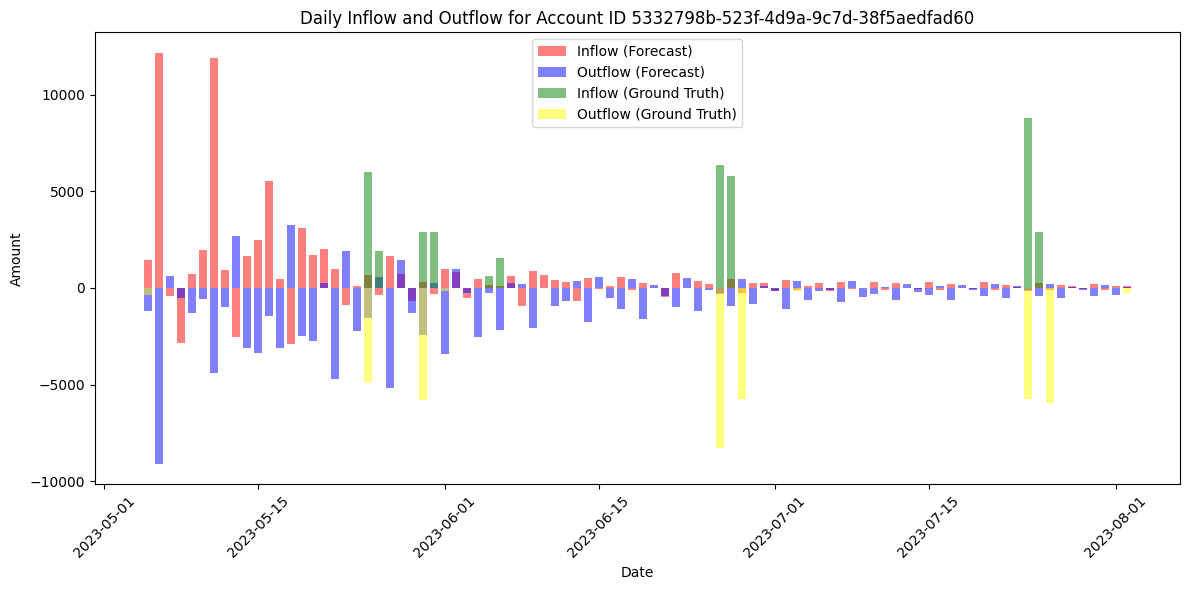

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
account_table=account_tables['5332798b-523f-4d9a-9c7d-38f5aedfad60']
# Plot inflow and outflow for account_tablee_end_train
plt.figure(figsize=(12, 6))

plt.bar(account_table_end_train['Datetime'][-90:], account_table_end_train['INFLOW'][-90:], width=0.7,
        label='Inflow (Forecast)', color='red', alpha=0.5)
plt.bar(account_table_end_train['Datetime'][-90:], account_table_end_train['OUTFLOW'][-90:], width=0.7,
        label='Outflow (Forecast)', color='blue', alpha=0.5)

# Plot inflow and outflow for account_balance
plt.bar(account_table['Datetime'][-90:], account_table['INFLOW'][-90:], width=0.7,
        label='Inflow (Ground Truth)', color='green', alpha=0.5)
plt.bar(account_table['Datetime'][-90:], account_table['OUTFLOW'][-90:], width=0.7,
        label='Outflow (Ground Truth)', color='yellow', alpha=0.5)

# Labels and titles
plt.xlabel('Date')
plt.ylabel('Amount')
plt.title(f'Daily Inflow and Outflow for Account ID {account_id}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

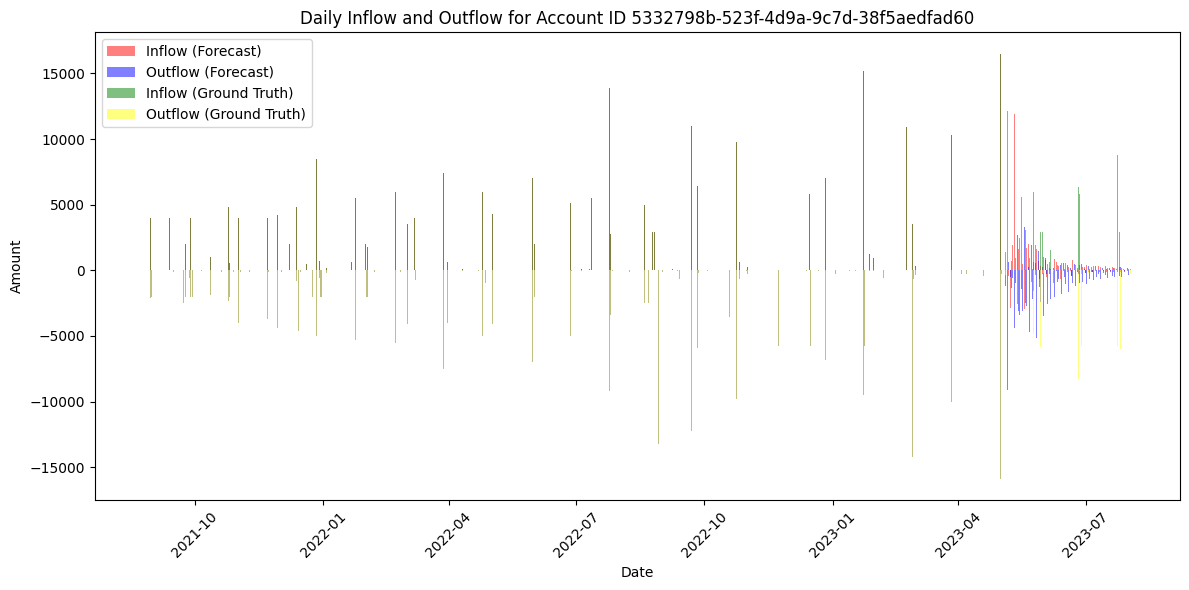

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
account_table=account_tables['5332798b-523f-4d9a-9c7d-38f5aedfad60']
# Plot inflow and outflow for account_tablee_end_train
plt.figure(figsize=(12, 6))

plt.bar(account_table_end_train['Datetime'], account_table_end_train['INFLOW'], width=0.7,
        label='Inflow (Forecast)', color='red', alpha=0.5)
plt.bar(account_table_end_train['Datetime'], account_table_end_train['OUTFLOW'], width=0.7,
        label='Outflow (Forecast)', color='blue', alpha=0.5)

# Plot inflow and outflow for account_balance
plt.bar(account_table['Datetime'][30:], account_table['INFLOW'][30:], width=0.7,
        label='Inflow (Ground Truth)', color='green', alpha=0.5)
plt.bar(account_table['Datetime'][30:], account_table['OUTFLOW'][30:], width=0.7,
        label='Outflow (Ground Truth)', color='yellow', alpha=0.5)

# Labels and titles
plt.xlabel('Date')
plt.ylabel('Amount')
plt.title(f'Daily Inflow and Outflow for Account ID {account_id}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
# Specify the path to the pickle file you want to read
pickle_file_path_2 = 'account.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path_2, 'rb') as file:
    # Load the data from the pickle file
    loaded_data_2 = pickle.load(file)

In [ ]:
account_balances = {}  # Create an empty dictionary
grouped_by_account_2 = loaded_data_2.groupby('id')

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
for id, group in grouped_by_account_2:
    if id in account_tables:
        account_table = account_tables[id]  # Get the corresponding account table
        filtered_2 = loaded_data_2[loaded_data_2['id'] == id]  # Filter loaded_data_2 for the specific account_id
        if filtered_2['type'].iloc[0] == 'DEPOSIT':
          final_balance = filtered_2['balance_available_amount'].iloc[0]
          final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

          date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
          account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

          current_balance = final_balance

          table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

          for index, row in table_sorted_reverse.iterrows():
              inflow = row['INFLOW']
              outflow = row['OUTFLOW']
              date_ = row['Datetime']
              current_balance = current_balance - inflow + outflow
              new_row = {'date': date_, 'balance': current_balance}
              account_balance = account_balance.append(new_row, ignore_index=True)
        elif filtered_2['type'].iloc[0] == 'CREDIT':
            final_balance = filtered_2['balance_current_amount'].iloc[0]
            final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

            date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
            account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

            current_balance = final_balance

            table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

            for index, row in table_sorted_reverse.iterrows():
                inflow = row['INFLOW']
                outflow = row['OUTFLOW']
                date_ = row['Datetime']
                current_balance = current_balance + inflow - outflow
                new_row = {'date': date_, 'balance': current_balance}
                account_balance = account_balance.append(new_row, ignore_index=True)

        account_balance = account_balance.sort_values(by='date', ascending=True)
        account_balances[id] = account_balance

# Now, account_balances contains a dictionary where each account ID is associated with a DataFrame containing final_balance and historical_balances


Görüntülenen çıkış son 5000 satıra kısaltıldı.
<ipython-input-26-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-26-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-26-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-26-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index

In [ ]:
import pandas as pd

# Assuming you have a dictionary called account_balances

for id, df in account_balances.items():
    # Convert 'date' to datetime if it's not already in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Set 'date' as index
    df.set_index('date', inplace=True)

    # Resample the data to have daily frequency
    df_resampled = df.resample('D').last()

    # Fill missing values with the last known balance (forward fill)
    df_resampled['balance'].fillna(method='ffill', inplace=True)

    # Reset index to get 'date' back as a column
    df_resampled.reset_index(inplace=True)

    # Store the modified DataFrame back in account_balances
    account_balances[id] = df_resampled

    # Print the modified DataFrame
    print(df_resampled)


          date  balance
0   2021-08-02  -899.61
1   2021-08-03  -699.61
2   2021-08-04  -699.61
3   2021-08-05  -699.61
4   2021-08-06  -699.61
..         ...      ...
727 2023-07-30   500.51
728 2023-07-31   500.51
729 2023-08-01   500.51
730 2023-08-02   500.51
731 2023-08-03   500.57

[732 rows x 2 columns]
          date    balance
0   2021-07-28 -589904.42
1   2021-07-29 -583904.42
2   2021-07-30 -581909.42
3   2021-07-31 -581909.42
4   2021-08-01 -581909.42
..         ...        ...
731 2023-07-29    3195.00
732 2023-07-30    3195.00
733 2023-07-31    3195.00
734 2023-08-01    3195.00
735 2023-08-02    3459.10

[736 rows x 2 columns]
          date    balance
0   2021-07-27  310003.97
1   2021-07-28  309347.50
2   2021-07-29  309315.28
3   2021-07-30  309267.53
4   2021-07-31  309218.28
..         ...        ...
732 2023-07-29     265.50
733 2023-07-30     265.50
734 2023-07-31     265.50
735 2023-08-01     199.07
736 2023-08-02      55.24

[737 rows x 2 columns]
          date  

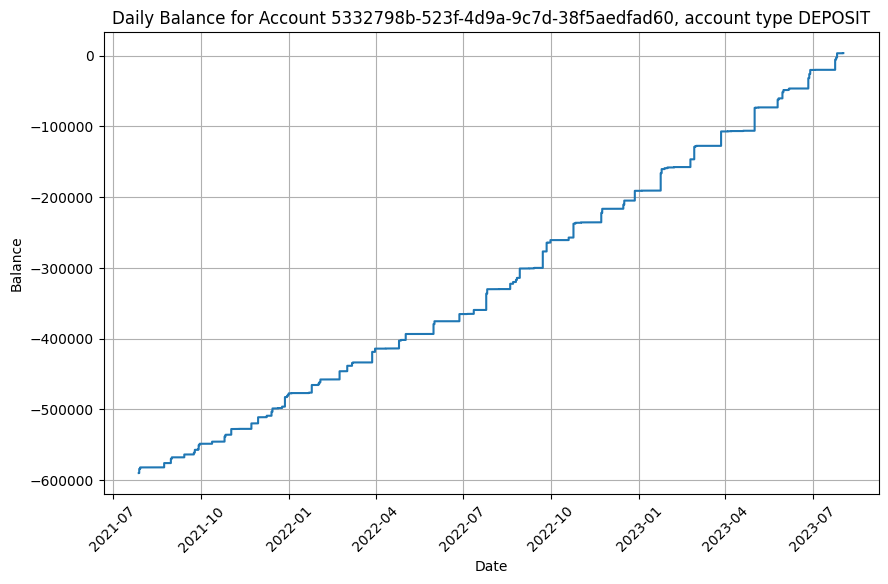

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have account_balances available

def plot_daily_balance(account_id):
    account_balance = account_balances.get(account_id)

    if account_balance is not None:
        account_type = loaded_data_2[loaded_data_2['id'] == account_id]['type'].iloc[0]
        plt.figure(figsize=(10, 6))
        plt.step(account_balance['date'], account_balance['balance'], where='mid')
        plt.title(f'Daily Balance for Account {account_id}, account type {account_type}')
        plt.xlabel('Date')
        plt.ylabel('Balance')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()
    else:
        print(f'Account ID {account_id} not found in account_balances.')

# Example usage:
plot_daily_balance('5332798b-523f-4d9a-9c7d-38f5aedfad60')

In [ ]:
# Creating balance graphs from the predicted inflow outflow values
filtered_2 = loaded_data_2[loaded_data_2['id'] == '5332798b-523f-4d9a-9c7d-38f5aedfad60']
if filtered_2['type'].iloc[0] == 'DEPOSIT':
  final_balance = account_balances['5332798b-523f-4d9a-9c7d-38f5aedfad60']['balance'].iloc[-90]
  #final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()
  final_date=account_balances['5332798b-523f-4d9a-9c7d-38f5aedfad60']['date'].iloc[-90]
  date_range = pd.date_range(start=account_table_end_train['Datetime'].min(), end=final_date)
  account_table_end_train_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

  current_balance = final_balance

  table_sorted_reverse = account_table_end_train[-30:].sort_values(by='Datetime', ascending=False)

  for index, row in table_sorted_reverse.iterrows():
      inflow = row['INFLOW']
      outflow = row['OUTFLOW']
      date_ = row['Datetime']
      current_balance = current_balance + inflow - outflow
      new_row = {'date': date_, 'balance': current_balance}
      account_table_end_train_balance= account_table_end_train_balance.append(new_row, ignore_index=True)
elif filtered_2['type'].iloc[0] == 'CREDIT':
    final_balance = filtered_2['balance_current_amount'].iloc[0]
    final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

    date_range = pd.date_range(start=account_table_end_train['Datetime'].min(), end=final_date)
    account_table_end_train_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

    current_balance = final_balance

    table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

    for index, row in table_sorted_reverse.iterrows():
        inflow = row['INFLOW']
        outflow = row['OUTFLOW']
        date_ = row['Datetime']
        current_balance = current_balance - inflow + outflow
        new_row = {'date': date_, 'balance': current_balance}
        account_table_end_train_balance = account_table_end_train_balance.append(new_row, ignore_index=True)

account_table_end_train_balance = account_table_end_train_balance.sort_values(by='date', ascending=True)


<ipython-input-29-07da37468344>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train_balance= account_table_end_train_balance.append(new_row, ignore_index=True)
<ipython-input-29-07da37468344>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train_balance= account_table_end_train_balance.append(new_row, ignore_index=True)
<ipython-input-29-07da37468344>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_end_train_balance= account_table_end_train_balance.append(new_row, ignore_index=True)
<ipython-input-29-07da37468344>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_table_en

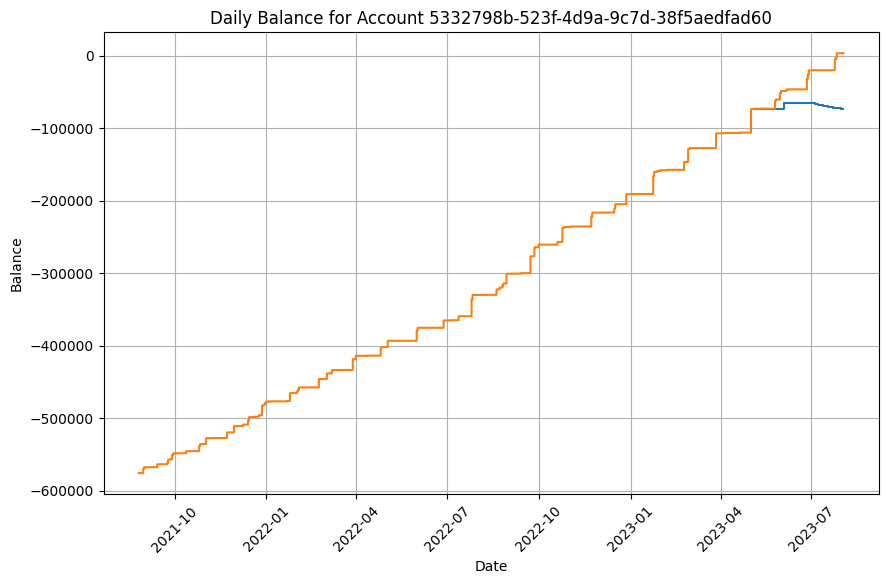

In [ ]:
#account_type = loaded_data_2[loaded_data_2['id'] == account_id]['type'].iloc[0]
plt.figure(figsize=(10, 6))
plt.step(account_table_end_train_balance['date'], account_table_end_train_balance['balance'], where='mid')
plt.step(account_balances['5332798b-523f-4d9a-9c7d-38f5aedfad60']['date'][29:], account_balances['5332798b-523f-4d9a-9c7d-38f5aedfad60']['balance'][29:], where='mid')
plt.title(f'Daily Balance for Account {account_id}')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()